# Customer Churn Prediction — EDA & Data Preparation

## Problem Statement

In this project, we will analyze customer information and behavior to understand the factors associated with **telecom customer churn**.

We have two datasets:

- **Client.csv** — customer profile and demographic information.
- **Record.csv** — customer usage, revenue, and behavioral information.

Both datasets contain `Customer_ID`, which will be used to combine the datasets.

### Main Goal

The goal of this notebook is to:

1. Load and understand the data
2. Merge the two datasets
3. Analyze customer churn
4. Perform exploratory data analysis (EDA)
5. Clean the feature data
6. Create meaningful engineered features
7. Prepare the final feature dataset for the model-training notebook

> **Note:** Encoding, scaling, feature selection, feature importance, and model training will be performed in the separate **Model Training** notebook.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

##  Data Loading

In [2]:
client = pd.read_csv("Client.csv")
record = pd.read_csv("Record.csv")

print("Client Shape:", client.shape)
print("Record Shape:", record.shape)

Client Shape: (100000, 50)
Record Shape: (100000, 51)


In [3]:
client.head()

,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID
0,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0,1000001
1,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0,1000002
2,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0,1000003
3,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,T,CHICAGO AREA,N,N,29.98999,1.0,1.0,NaN,0.0,0.0,NaN,6.0,M,M,4.0,M,6.0,1.0,C,D,0.0,U,Y,U,U,U,U,Y,1812.0,1000004
4,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,U,NEW ENGLAND AREA,Y,N,149.98999,6.0,4.0,WCMB,0.0,0.0,R,5.0,M,S,1.0,M,6.0,1.0,C,O,0.0,I,U,U,U,U,U,Y,434.0,1000005


In [4]:
client.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 50 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   uniqsubs          100000 non-null  int64  
 1   actvsubs          100000 non-null  int64  
 2   new_cell          100000 non-null  str    
 3   crclscod          100000 non-null  str    
 4   asl_flag          100000 non-null  str    
 5   totcalls          100000 non-null  int64  
 6   totmou            100000 non-null  float64
 7   totrev            100000 non-null  float64
 8   adjrev            100000 non-null  float64
 9   adjmou            100000 non-null  float64
 10  adjqty            100000 non-null  int64  
 11  avgrev            100000 non-null  float64
 12  avgmou            100000 non-null  float64
 13  avgqty            100000 non-null  float64
 14  avg3mou           100000 non-null  int64  
 15  avg3qty           100000 non-null  int64  
 16  avg3rev           100000 non-nul

### Data Integration

The `Client` and `Record` datasets contain different types of information about the same customers.

Both datasets share `Customer_ID`, which is used as the common key.

A left merge is performed using `Client` as the base so that all customers from the Client dataset are retained.

In [5]:
df = pd.merge(
    client,
    record,
    on="Customer_ID",
    how="left"
)

print("Merged dataset shape:", df.shape)

Merged dataset shape: (100000, 100)


In [6]:
df.head()

,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months
0,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0,1000001,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61
1,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0,1000002,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56
2,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0,1000003,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58
3,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,T,CHICAGO AREA,N,N,29.98999,1.0,1.0,NaN,0.0,0.0,NaN,6.0,M,M,4.0,M,6.0,1.0,C,D,0.0,U,Y,U,U,U,U,Y,1812.0,1000004,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60
4,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,U,NEW ENGLAND AREA,Y,N,149.98999,6.0,4.0,WCMB,0.0,0.0,R,5.0,M,S,1.0,M,6.0,1.0,C,O,0.0,I,U,U,U,U,U,Y,434.0,1000005,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 100 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   uniqsubs          100000 non-null  int64  
 1   actvsubs          100000 non-null  int64  
 2   new_cell          100000 non-null  str    
 3   crclscod          100000 non-null  str    
 4   asl_flag          100000 non-null  str    
 5   totcalls          100000 non-null  int64  
 6   totmou            100000 non-null  float64
 7   totrev            100000 non-null  float64
 8   adjrev            100000 non-null  float64
 9   adjmou            100000 non-null  float64
 10  adjqty            100000 non-null  int64  
 11  avgrev            100000 non-null  float64
 12  avgmou            100000 non-null  float64
 13  avgqty            100000 non-null  float64
 14  avg3mou           100000 non-null  int64  
 15  avg3qty           100000 non-null  int64  
 16  avg3rev           100000 non-nu

In [8]:
print("Unique Customer IDs:", df["Customer_ID"].nunique())
print("Total Rows:", len(df))

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Customer_IDs:", df["Customer_ID"].duplicated().sum())

Unique Customer IDs: 100000
Total Rows: 100000
Duplicate rows: 0
Duplicate Customer_IDs: 0


### Separating Features and Target

The `churn` column is the target variable.

- **X (Features):** variables used to predict customer churn
- **y (Target):** whether the customer churned

The target is kept separate from the feature data throughout the cleaning and feature-engineering process.

In [9]:
X = df.drop(columns=["churn"])
y = df["churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (100000, 99)
Target shape: (100000,)


### Numerical and Categorical Features

The dataset contains both numerical and categorical variables.

We identify them automatically from their data types rather than manually listing every column.

- **Numerical features** will later be suitable for scaling.
- **Categorical features** will later be encoded using One-Hot Encoding.

Encoding and scaling are intentionally saved for the Model Training notebook.

In [10]:
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print("Number of Numerical Features:", len(num_cols))
print("Number of Categorical Features:", len(cat_cols))

print("\nNumerical Features:")
print(num_cols)

print("\nCategorical Features:")
print(cat_cols)

Number of Numerical Features: 78
Number of Categorical Features: 21

Numerical Features:
['uniqsubs', 'actvsubs', 'totcalls', 'totmou', 'totrev', 'adjrev', 'adjmou', 'adjqty', 'avgrev', 'avgmou', 'avgqty', 'avg3mou', 'avg3qty', 'avg3rev', 'avg6mou', 'avg6qty', 'avg6rev', 'hnd_price', 'phones', 'models', 'truck', 'rv', 'lor', 'adults', 'income', 'numbcars', 'forgntvl', 'eqpdays', 'Customer_ID', 'rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean', 'ovrrev_Mean', 'vceovr_Mean', 'datovr_Mean', 'roam_Mean', 'change_mou', 'change_rev', 'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean', 'blck_dat_Mean', 'unan_vce_Mean', 'unan_dat_Mean', 'plcd_vce_Mean', 'plcd_dat_Mean', 'recv_vce_Mean', 'recv_sms_Mean', 'comp_vce_Mean', 'comp_dat_Mean', 'custcare_Mean', 'ccrndmou_Mean', 'cc_mou_Mean', 'inonemin_Mean', 'threeway_Mean', 'mou_cvce_Mean', 'mou_cdat_Mean', 'mou_rvce_Mean', 'owylis_vce_Mean', 'mouowylisv_Mean', 'iwylis_vce_Mean', 'mouiwylisv_Mean', 'peak_vce_Mean', 'peak_dat_Mean', 'mou

### Target Analysis — Customer Churn

Before detailed EDA, we examine the distribution of the target variable.

- `0` → Customer did not churn
- `1` → Customer churned

This helps us determine whether the target is balanced or imbalanced.

In [11]:
print(y.value_counts())

print("\nTarget Percentage:")
print((y.value_counts(normalize=True) * 100).round(2))

churn
0    50438
1    49562
Name: count, dtype: int64

Target Percentage:
churn
0    50.44
1    49.56
Name: proportion, dtype: float64


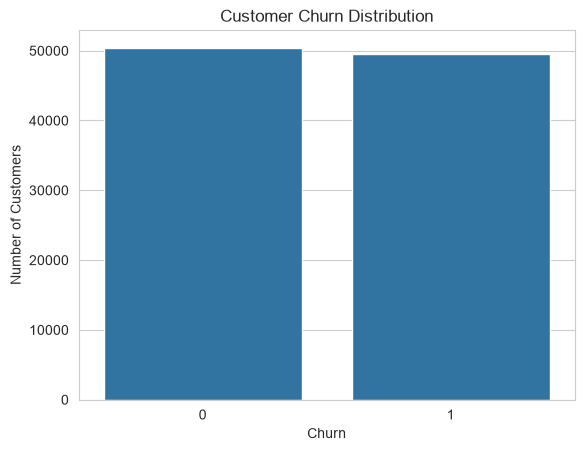

In [12]:
sns.countplot(x=y)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

### Numerical Feature Analysis

We examine the numerical variables using descriptive statistics and distributions.

This helps us identify:

- Different feature scales
- Skewed distributions
- Potential outliers
- Unusual values
- General customer usage and revenue patterns

In [13]:
X[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
uniqsubs,100000.0,1.548140,1.075255,1.00,1.000000,1.000000,2.000000,196.000000
actvsubs,100000.0,1.358960,0.655555,0.00,1.000000,1.000000,2.000000,53.000000
totcalls,100000.0,2877.141930,3790.863474,0.00,889.000000,1822.000000,3492.000000,98874.000000
totmou,100000.0,7648.363833,8666.558293,0.00,2529.000000,5191.500000,9776.000000,233419.096700
totrev,100000.0,1031.924988,852.907511,3.65,518.980000,804.530000,1263.767500,27321.500000
...,...,...,...,...,...,...,...,...
attempt_Mean,100000.0,145.752225,159.348094,0.00,38.333333,101.000000,199.666667,2289.000000
complete_Mean,100000.0,109.666977,119.594305,0.00,28.666667,76.000000,150.666667,1894.333333
callfwdv_Mean,100000.0,0.011700,0.547470,0.00,0.000000,0.000000,0.000000,81.333333
callwait_Mean,100000.0,1.782928,5.353953,0.00,0.000000,0.333333,1.333333,212.666667


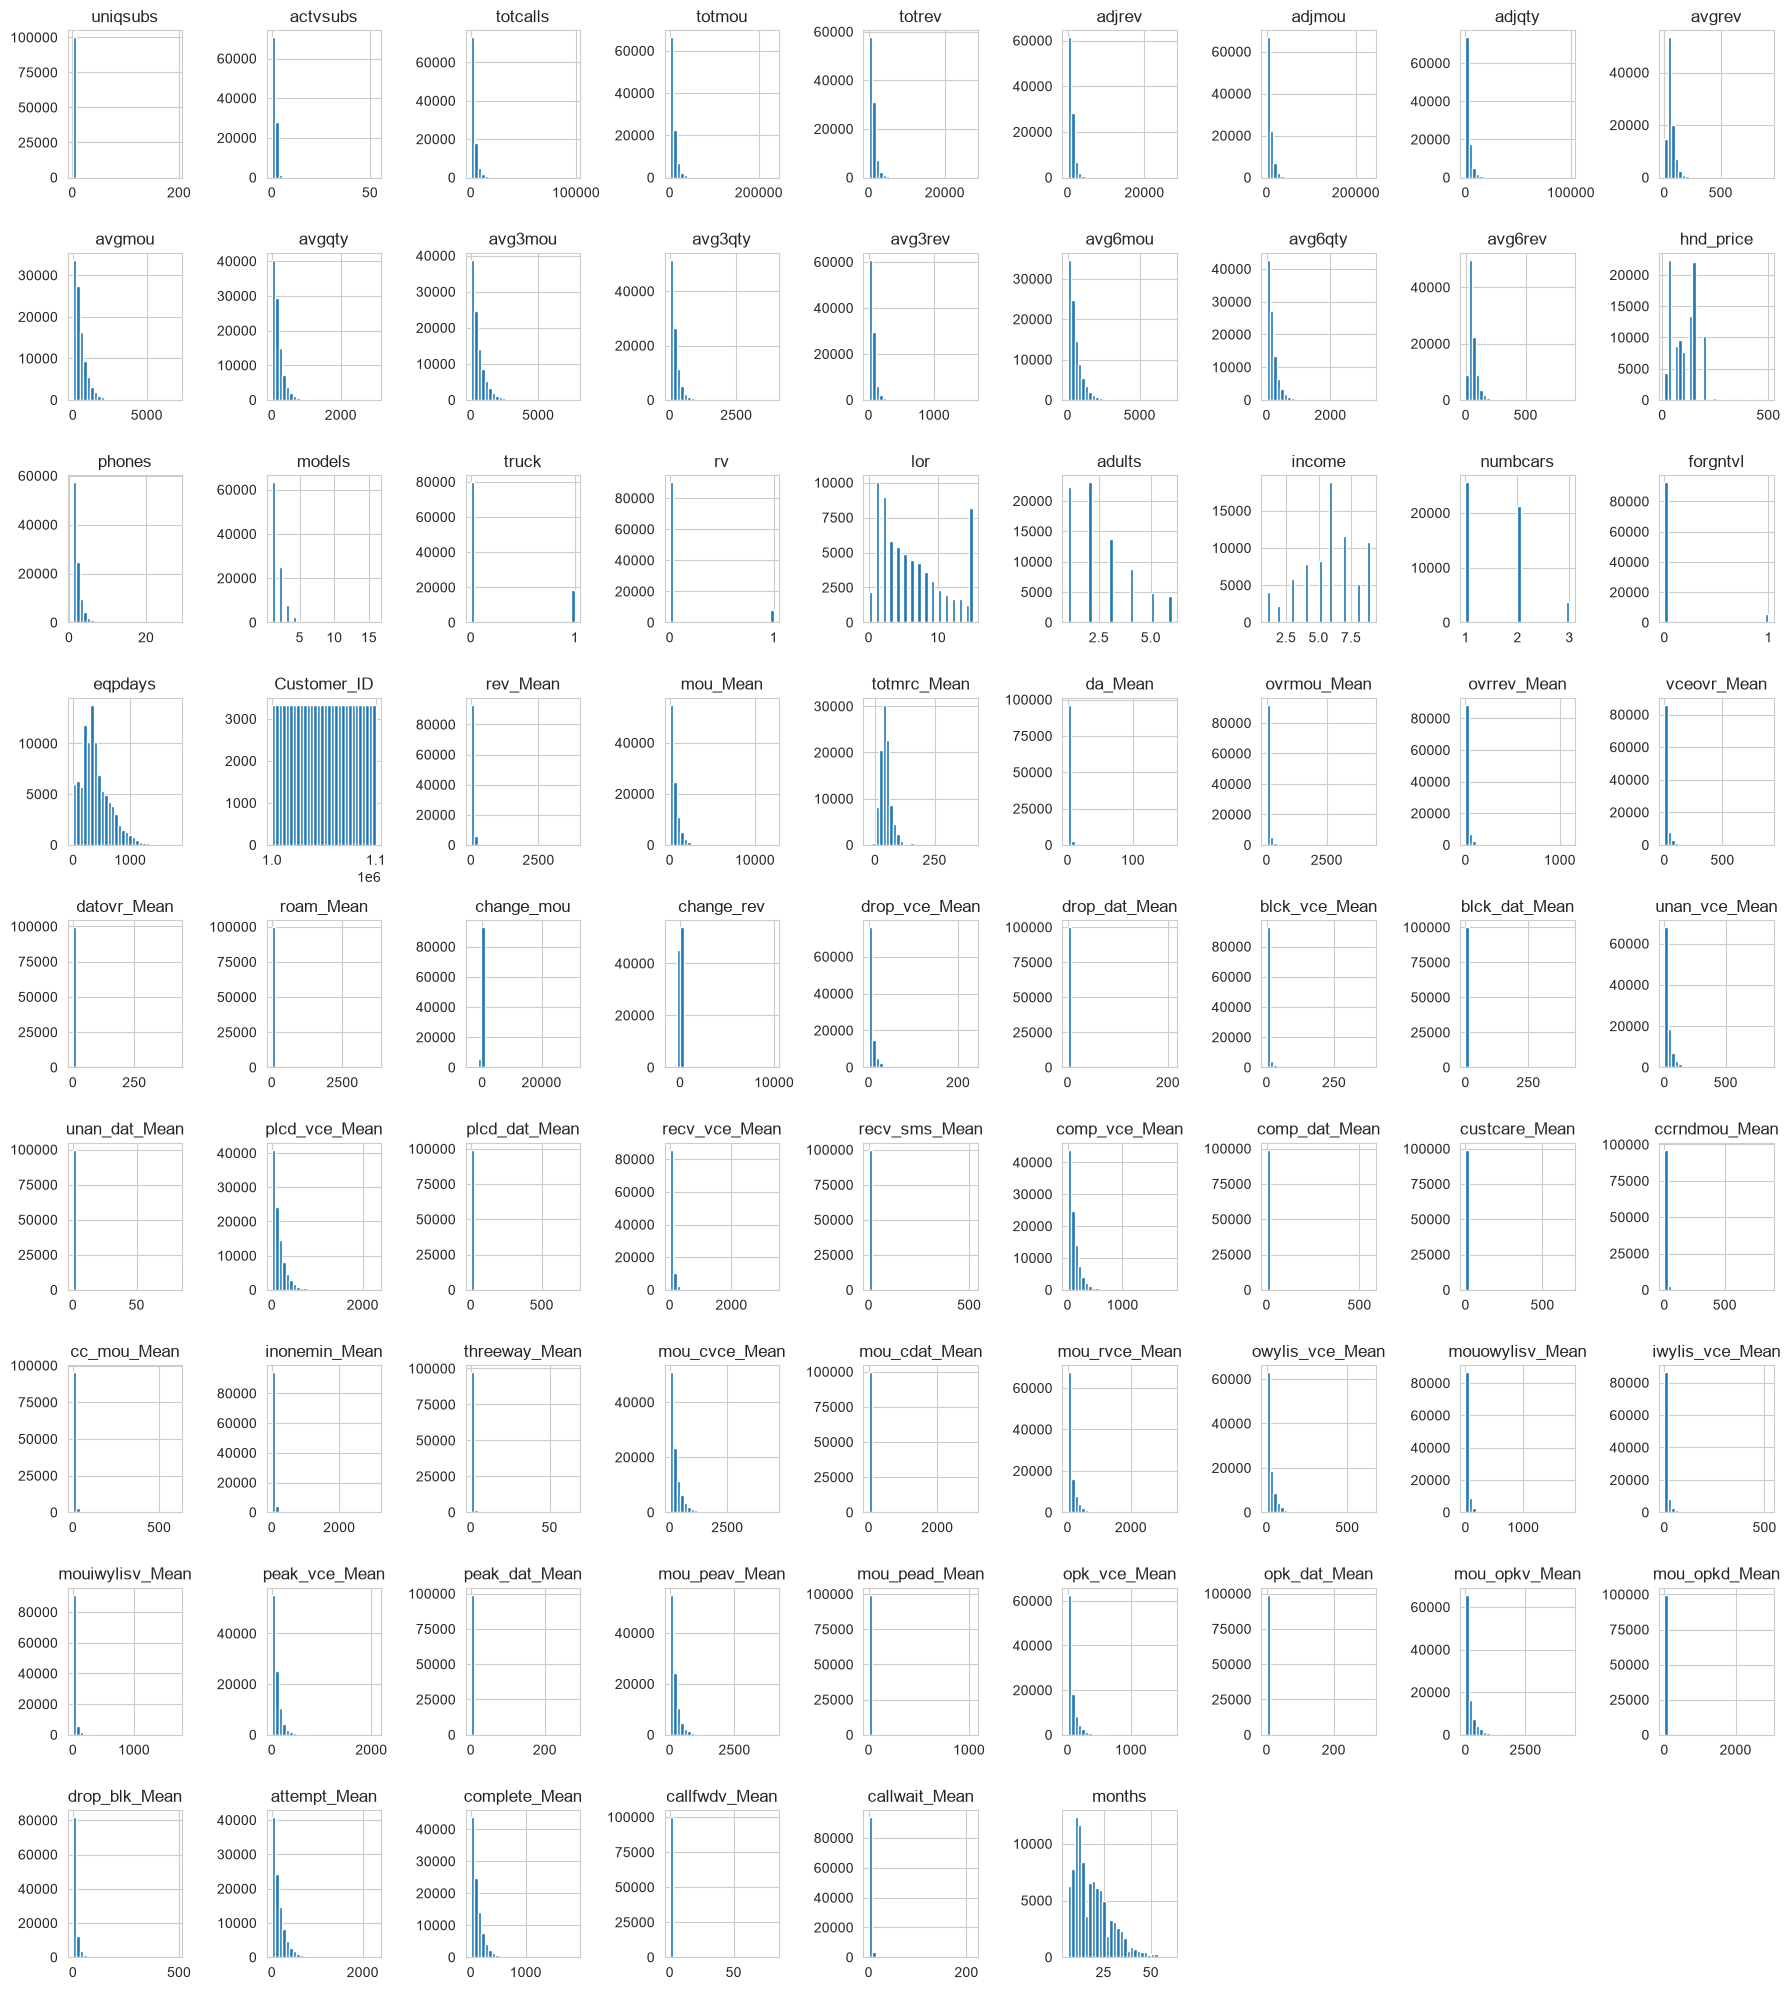

In [14]:
X[num_cols].hist(
    figsize=(18, 20),
    bins=30
)

plt.tight_layout()
plt.show()

### Categorical Feature Analysis

We examine the number of unique categories in each categorical feature.

This is useful for understanding the structure of the categorical variables and identifying columns with very high or very low cardinality.

In [15]:
cat_unique = X[cat_cols].nunique().sort_values(ascending=False)
cat_unique

crclscod            54
area                19
ethnic              17
dwllsize            15
HHstatin             6
prizm_social_one     5
marital              5
dualband             4
new_cell             3
hnd_webcap           3
asl_flag             2
ownrent              2
refurb_new           2
infobase             2
dwlltype             2
kid0_2               2
kid3_5               2
kid6_10              2
kid11_15             2
kid16_17             2
creditcd             2
dtype: int64

### Missing Value Analysis

Missing values are analyzed in the feature dataset `X`, excluding the target.

We inspect both the number and percentage of missing values for each feature.

In [16]:
missing = pd.DataFrame({
    "Missing_Count": X.isnull().sum(),
    "Missing_Percentage": (X.isnull().sum() / len(X)) * 100
})

missing = missing[missing["Missing_Count"] > 0].sort_values(
    "Missing_Percentage",
    ascending=False
)

missing

,Missing_Count,Missing_Percentage
numbcars,49366,49.366
dwllsize,38308,38.308
HHstatin,37923,37.923
ownrent,33706,33.706
dwlltype,31909,31.909
lor,30190,30.190
income,25436,25.436
adults,23019,23.019
infobase,22079,22.079
hnd_webcap,10189,10.189


### Data Cleaning

We will clean the feature dataset without modifying the target.

### Numerical features
Missing numerical values are filled using the **median**. This is more robust than the mean when variables contain skewness or outliers.

### Categorical features
Missing categorical values are replaced with **`Unknown`**. This preserves the information that the original value was missing instead of forcing it into the most common category.

After cleaning, we verify that there are no missing values.

In [17]:
# Create a separate cleaned feature dataset
X_clean = X.copy()

# Numerical missing values → median
for col in num_cols:
    if X_clean[col].isnull().any():
        X_clean[col] = X_clean[col].fillna(X_clean[col].median())

# Categorical missing values → Unknown
for col in cat_cols:
    if X_clean[col].isnull().any():
        X_clean[col] = X_clean[col].fillna("Unknown")

print("Missing values after cleaning:", X_clean.isnull().sum().sum())

Missing values after cleaning: 0


In [18]:
print("Shape:", X_clean.shape)
print("Missing values:", X_clean.isnull().sum().sum())
print("Duplicate rows:", X_clean.duplicated().sum())

Shape: (100000, 99)
Missing values: 0
Duplicate rows: 0


### Feature Engineering

Feature engineering creates additional variables that represent useful customer behavior more directly.

We will create a small number of business-meaningful features:

- **Revenue per Call** — average revenue generated per call
- **Minutes per Call** — average call duration
- **Revenue per Month** — revenue relative to customer tenure
- **Recent Usage Change** — difference between recent and overall average usage
- **Recent Revenue Change** — difference between recent and overall average revenue

These features are created from the cleaned feature dataset `X_clean`.

We will evaluate their usefulness later in the Model Training notebook.

In [19]:
# Feature Engineering

X_clean["revenue_per_call"] = (
    X_clean["totrev"] / X_clean["totcalls"].replace(0, np.nan)
)

X_clean["minutes_per_call"] = (
    X_clean["totmou"] / X_clean["totcalls"].replace(0, np.nan)
)

X_clean["revenue_per_month"] = (
    X_clean["totrev"] / X_clean["months"].replace(0, np.nan)
)

X_clean["mou_change_recent"] = (
    X_clean["avg3mou"] - X_clean["avgmou"]
)

X_clean["rev_change_recent"] = (
    X_clean["avg3rev"] - X_clean["avgrev"]
)

In [20]:
new_features = [
    "revenue_per_call",
    "minutes_per_call",
    "revenue_per_month",
    "mou_change_recent",
    "rev_change_recent"
]

# Handle values created by division
X_clean[new_features] = X_clean[new_features].replace(
    [np.inf, -np.inf],
    np.nan
)

X_clean[new_features] = X_clean[new_features].fillna(0)

print("New features:")
print(new_features)

print("\nMissing values in new features:")
print(X_clean[new_features].isnull().sum())

New features:
['revenue_per_call', 'minutes_per_call', 'revenue_per_month', 'mou_change_recent', 'rev_change_recent']

Missing values in new features:
revenue_per_call     0
minutes_per_call     0
revenue_per_month    0
mou_change_recent    0
rev_change_recent    0
dtype: int64


In [21]:
X_clean[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
revenue_per_call,100000.0,0.837871,4.736064,0.0000,0.292796,0.437099,0.706594,882.220000
minutes_per_call,100000.0,2.973148,1.371445,0.0000,2.136249,2.633096,3.385265,34.556164
revenue_per_month,100000.0,56.348107,33.619907,0.0625,35.282698,48.918361,67.699137,881.338710
mou_change_recent,100000.0,35.914718,247.333896,-3348.5600,-54.780000,8.735000,105.282500,3851.600000
rev_change_recent,100000.0,1.279498,28.553223,-732.2700,-7.050000,-0.440000,5.890000,1207.250000


### Remove Identifier Columns

`Customer_ID` is an identifier and does not represent customer behavior.

It should not be used as a predictive feature because the model could learn meaningless patterns from the ID values.

We therefore remove it from the final feature dataset.

In [22]:
X_clean = X_clean.drop(columns=["Customer_ID"])

print("Final feature count:", X_clean.shape[1])
print("Customer_ID present:", "Customer_ID" in X_clean.columns)

Final feature count: 103
Customer_ID present: False


### Final Data Validation

Before moving to the Model Training notebook, we verify that the final feature dataset is clean.

The final dataset should have:

- No missing values
- No duplicate rows
- No identifier column
- All engineered features included
- The target `y` kept separately

In [23]:
print("Final X shape:", X_clean.shape)
print("Target shape:", y.shape)
print("Missing values:", X_clean.isnull().sum().sum())
print("Duplicate rows:", X_clean.duplicated().sum())
print("Customer_ID present:", "Customer_ID" in X_clean.columns)

print("\nNew features present:")
print([feature for feature in new_features if feature in X_clean.columns])

Final X shape: (100000, 103)
Target shape: (100000,)
Missing values: 0
Duplicate rows: 0
Customer_ID present: False

New features present:
['revenue_per_call', 'minutes_per_call', 'revenue_per_month', 'mou_change_recent', 'rev_change_recent']


In [24]:
print("Final feature count:", X_clean.shape[1])
print("\nFinal feature names:")
print(X_clean.columns.tolist())

Final feature count: 103

Final feature names:
['uniqsubs', 'actvsubs', 'new_cell', 'crclscod', 'asl_flag', 'totcalls', 'totmou', 'totrev', 'adjrev', 'adjmou', 'adjqty', 'avgrev', 'avgmou', 'avgqty', 'avg3mou', 'avg3qty', 'avg3rev', 'avg6mou', 'avg6qty', 'avg6rev', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_price', 'phones', 'models', 'hnd_webcap', 'truck', 'rv', 'ownrent', 'lor', 'dwlltype', 'marital', 'adults', 'infobase', 'income', 'numbcars', 'HHstatin', 'dwllsize', 'forgntvl', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd', 'eqpdays', 'rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean', 'ovrrev_Mean', 'vceovr_Mean', 'datovr_Mean', 'roam_Mean', 'change_mou', 'change_rev', 'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean', 'blck_dat_Mean', 'unan_vce_Mean', 'unan_dat_Mean', 'plcd_vce_Mean', 'plcd_dat_Mean', 'recv_vce_Mean', 'recv_sms_Mean', 'comp_vce_Mean', 'comp_dat_Mean', 'custcare_Mean', 'ccrndmou_Mean', 'cc_mou_Mean', 'inon

### Save Cleaned Data for Model Training

The cleaned and feature-engineered data will be saved so that the Model Training notebook can start directly from the prepared dataset.

We will save:

- `X_clean.csv` → cleaned and engineered features
- `y.csv` → churn target

Encoding, scaling, feature selection, feature importance, model training, evaluation, and hyperparameter tuning will be performed in the next notebook.

In [25]:
X_clean.to_csv("X_clean.csv", index=False)
y.to_csv("y.csv", index=False)

print("Saved X_clean.csv and y.csv")

Saved X_clean.csv and y.csv


## EDA Notebook Complete

### Completed

- Data loading
- Data integration
- Data understanding
- Target analysis
- Numerical EDA
- Categorical EDA
- Missing value analysis
- Data cleaning
- Feature engineering
- Identifier removal
- Final validation
- Saving prepared datasets

### Next Notebook — Model Training

The next notebook will cover:

**Train/Test Split → One-Hot Encoding → Scaling → Feature Selection → Feature Importance → Model Training → Evaluation → Hyperparameter Tuning → Final Model**